# MS2PIP, DeepLC & IM2Deep: Multi-modal Peptide Property Prediction

**Tool versions:** ms2pip, deeplc, im2deep — latest PyPI releases (see install cell)
**Estimated time:** 30 min
**Level:** intermediate
**Last tested:** 2026-06-10

## Abstract

This tutorial predicts three complementary LC-IM-MS/MS properties for real HeLa-derived
peptides using CompOmics tools: fragment ion intensities with
[MS2PIP](https://github.com/compomics/ms2pip), retention time with
[DeepLC](https://github.com/compomics/DeepLC), and collisional cross-section with
[IM2Deep](https://github.com/compomics/IM2Deep). Each prediction is benchmarked against
real experimental data: an MS2PIP spectrum is compared to an observed, identified
spectrum pulled from the raw ProteomeXchange deposition; DeepLC predictions are compared
raw, calibrated, and fine-tuned; and IM2Deep's multi-conformer model is compared to a
real bimodal ion mobilogram extracted directly from a Bruker `.d` file.

| Tool | Prediction | Model |
|------|-----------|-------|
| [MS2PIP](https://github.com/compomics/ms2pip) | Fragment ion intensities (b/y) | timsTOF |
| [DeepLC](https://github.com/compomics/DeepLC) | Retention time (RT) | Default (raw / calibrated / fine-tuned) |
| [IM2Deep](https://github.com/compomics/IM2Deep) | Collisional cross-section (CCS) | TIMS - single- and multi-conformer |

## Learning objectives

By the end of this tutorial, you will be able to:

- Convert MaxQuant modified-sequence notation to ProForma
- Predict fragment ion intensities with MS2PIP and compare them to a real observed,
  identified spectrum, both for individual spectra and as a spectral angle distribution
  across many spectra
- Predict retention time with DeepLC in raw, calibrated, and fine-tuned modes, and
  compare their accuracy against observed RT
- Predict CCS values with IM2Deep's single-conformer model and evaluate them against
  observed CCS
- Extract a real ion mobilogram from a Bruker `.d` file and use IM2Deep's
  multi-conformer model to predict the CCS of two co-occurring peptide conformations,
  contrasting it with the single-conformer model's prediction for the same peptide

## Prerequisites

- Familiarity with basic Python and pandas
- Basic understanding of peptide fragmentation (b/y-ions) and LC-IM-MS/MS

## Input data

- The [Meier *et al.* IM-CCS dataset](https://proteomicsml.org/datasets/ionmobility/Meier_IM_CCS/),
  hosted on [ProteomicsML](https://proteomicsml.org). It was acquired on a timsTOF Pro
  instrument and covers three ProteomeXchange depositions (PXD010012, PXD019086,
  PXD017703): 718 K high-confidence PSMs with observed retention time and CCS. The
  dataset (~23 MB) is downloaded directly from the ProteomicsML GitHub repository in
  Section 2. This dataset is used for the bulk DeepLC and IM2Deep benchmarks.
- Raw MaxQuant search results and, for one example, the raw Bruker `.d` file, from a
  single run of **PXD010012** (the same deposition underlying part of the Meier
  dataset above) — downloaded on demand in Sections 4 and 6 to obtain real observed
  spectra and a real ion mobilogram.

## 1. Setup

In [67]:
# Install dependencies (run once)
# !pip install ms2pip deeplc im2deep psm-utils tensorflow-cpu remotezip alphatims python-lzf

In [68]:
import io
import os
import re
import warnings
import zipfile

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import requests
import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.stats import pearsonr

import alphatims.bruker
import deeplc
import im2deep
import remotezip
from ms2pip import predict_batch
from psm_utils import PSM, PSMList

warnings.filterwarnings("ignore")  # silence noisy alphatims/pandas warnings


class _SilentTqdm(tqdm.tqdm):
    """Suppress tqdm progress bars (e.g. from alphatims) for cleaner notebook output."""

    def __init__(self, *args, **kwargs):
        kwargs["disable"] = True
        super().__init__(*args, **kwargs)


tqdm.tqdm = _SilentTqdm

In [69]:
%matplotlib inline

## 2. Dataset

The [Meier *et al.* IM-CCS dataset](https://proteomicsml.org/datasets/ionmobility/Meier_IM_CCS/)
was acquired on a timsTOF Pro instrument and covers three ProteomeXchange depositions
(PXD010012, PXD019086, PXD017703). It contains 718 K high-confidence PSMs with four
key measured properties:

| Column | Description |
|--------|-------------|
| `Modified sequence` | MaxQuant notation: underscores mark the termini, modifications in parentheses, e.g. `_AAEM(ox)K_` |
| `Charge` | Precursor charge state |
| `Retention time` | In **seconds** when `PT=False`; in **minutes** when `PT=True` |
| `CCS` | Collisional cross-section in Å², measured by TIMS |
| `PT` | Whether the peptide is a ProteomeTools synthetic peptide, run on a single, fixed ~45 min gradient. The `PT=False` rows instead pool a HeLa dilution series acquired on *several different* gradient lengths (5-120 min) with no run identifier to tell them apart, so they cannot be used for a single RT calibration (see Section 3). |

We download the dataset directly from the ProteomicsML GitHub repository.

In [70]:
url = (
    "https://raw.githubusercontent.com/ProteomicsML/ProteomicsML/main"
    "/datasets/ionmobility/Meier_IM_CCS/combined_sm.zip"
)

print("Downloading dataset (~23 MB)...")
response = requests.get(url, timeout=120)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df_raw = pd.read_csv(z.open("combined_sm.csv"))

print(f"Loaded {len(df_raw):,} PSMs")
df_raw.head()

Loaded 718,917 PSMs


,Unnamed: 0,Modified sequence,Charge,Mass,Intensity,Retention time,CCS,PT
0,0,_(ac)AAAAAAAAAAGAAGGR_,2,1239.63200,149810.0,70.140,409.092529,False
1,1,_(ac)AAAAAAAAEQQSSNGPVKK_,2,1810.91734,21349.0,19.645,481.229248,True
2,2,_(ac)AAAAAAAGAAGSAAPAAAAGAPGSGGAPSGSQGVLIGDR_,3,3144.55482,194000.0,3947.700,772.098083,False
3,3,_(ac)AAAAAAAGDSDSWDADAFSVEDPVRK_,2,2634.18340,6416400.0,94.079,573.213196,False
4,4,_(ac)AAAAAAAGDSDSWDADAFSVEDPVRK_,3,2634.18340,5400600.0,94.841,635.000549,False


## 3. Preprocessing

We apply the following steps:

1. **Convert** MaxQuant modified sequences to [ProForma](https://github.com/HUPO-PSI/ProForma)
   notation, which is the unified format accepted by all three tools. For example:
   `_AAEM(ox)K_` (charge 2) → `AAEM[Oxidation]K/2`
   Modifications are placed in square brackets immediately after the modified residue;
   the charge state follows a `/` suffix. N-terminal modifications use a `-` separator,
   e.g. `_(ac)PEPTIDE_` → `[Acetyl]-PEPTIDE/2`.
2. **Convert** `Retention time` to minutes. As noted in Section 2, its unit depends on
   `PT`: seconds for `PT=False`, already minutes for `PT=True`. Applying `/ 60`
   unconditionally to the whole column would silently divide the `PT=True` rows by 60 a
   second time.
3. **Keep only `PT=True`** (ProteomeTools) PSMs. The `PT=False` rows pool a HeLa
   dilution series acquired on several different gradient lengths without a run
   identifier to separate them, so a single RT value from that subset can mean very
   different things depending on which original run it came from — mixing them makes
   any single RT calibration meaningless (Pearson r stays below 0.2 even after
   calibration). The `PT=True` rows were all measured on one fixed gradient, which is
   what a real single-LC-system benchmark requires.
4. **Sample** 500 PSMs for the predictions.

In [ ]:
MQ_MOD_MAP = {
    "ac": "Acetyl",
    "ox": "Oxidation",
    "ca": "Carbamidomethyl",
    "de": "Deamidated",
    "ph": "Phospho",
}


def mq_to_proforma(mq_seq: str, charge: int) -> str:
    """Convert MaxQuant modified sequence to ProForma notation."""
    seq = mq_seq.strip("_")
    nterm_m = re.match(r"^\((\w+)\)", seq)
    nterm = ""
    if nterm_m:
        nterm = f"[{MQ_MOD_MAP.get(nterm_m.group(1), nterm_m.group(1))}]-"
        seq = seq[nterm_m.end() :]
    seq = re.sub(
        r"\((\w+)\)",
        lambda m: f"[{MQ_MOD_MAP.get(m.group(1), m.group(1))}]",
        seq,
    )
    return f"{nterm}{seq}/{charge}"


df_raw["proforma"] = df_raw.apply(
    lambda r: mq_to_proforma(r["Modified sequence"], r["Charge"]), axis=1
)
df_raw["sequence"] = (
    df_raw["Modified sequence"].str.strip("_").str.replace(r"\(\w+\)", "", regex=True)
)
# Retention time is in seconds for PT=False but already in minutes for PT=True --
# convert each group with its own unit.
df_raw["rt_min"] = np.where(
    df_raw["PT"], df_raw["Retention time"], df_raw["Retention time"] / 60
)
df_raw = df_raw[df_raw["sequence"].str.len().between(8, 20)]

# Keep only the ProteomeTools (PT=True) PSMs: the PT=False rows pool several different
# gradient lengths with no run identifier, so they cannot support a single RT calibration.
df_raw = df_raw[df_raw["PT"]]

sample = df_raw.sample(500, random_state=42).reset_index(drop=True)
print(f"Filtered dataset: {len(df_raw):,} PSMs")
print(f"Working sample:   {len(sample)} PSMs")
sample[["Modified sequence", "proforma", "rt_min", "CCS"]].head()

In [ ]:
# Build a shared PSMList for the 500-peptide sample, used by DeepLC and IM2Deep below
psm_list = PSMList(
    psm_list=[
        PSM(
            peptidoform=row["proforma"],
            spectrum_id=str(i),
            retention_time=row["rt_min"],
        )
        for i, row in sample.iterrows()
    ]
)
print(f"Built PSMList with {len(psm_list)} PSMs")

## 4. MS2PIP: Fragment Ion Intensity Prediction

[MS2PIP](https://github.com/compomics/ms2pip) predicts the relative intensities of
b- and y-fragment ions produced by collisional fragmentation (HCD). The two ion series
are complementary: b-ions retain the peptide N-terminus, y-ions retain the C-terminus.
For tryptic peptides ending in Lys or Arg, the y-ion series is typically dominant because
the basic C-terminal residue stabilises the y-ion charge.

We use the `timsTOF` model, which was trained on a large TOF fragmentation dataset and
supports unmodified and commonly modified peptides (oxidation, carbamidomethylation,
acetylation, phosphorylation).

> **Note**: the Meier dataset used above contains only RT and CCS values, not raw MS2
> spectra, so it cannot provide an observed spectrum to compare against. Instead, we
> pull a handful of confidently identified PSMs — with their matched, observed
> fragment ions — directly from the MaxQuant search results of one raw run in
> **PXD010012**, and predict a spectrum for each with MS2PIP.

### 4.1 Downloading real observed spectra

MaxQuant's `msms.txt` search result table stores, for every identified spectrum, the
list of matched fragment ions (`Matches`), their m/z (`Masses`), and their observed
intensities (`Intensities`) — i.e. a ready-made observed spectrum for every PSM. We
download this file for a single small HeLa run (`HeLa_5min`, ~50 ng on column) from
PXD010012 and keep all unmodified, charge-2, high-confidence PSMs from it: the top 4
(by number of matched fragment ions) are used below for a detailed, per-ion look at the
predicted vs. observed spectrum, and the full set is used in Section 4.3 to look at
prediction accuracy at scale.

We use `remotezip` to stream only the single file we need out of the PRIDE FTP archive,
rather than downloading the full submission.

In [73]:
RAW_RUN = "20180924_50ngHeLa_1.0.25.1_Hystar5.0SR1_S2-B4_1_2057"
MSMS_URL = (
    "https://ftp.pride.ebi.ac.uk/pride/data/archive/2018/11/PXD010012/HeLa_5min_txt.zip"
)
MSMS_PATH = "data/msms_HeLa_5min.txt"

if not os.path.exists(MSMS_PATH):
    os.makedirs("data", exist_ok=True)
    print("Downloading msms.txt (~100 MB, streamed from the PRIDE archive)...")
    with remotezip.RemoteZip(MSMS_URL) as zf:
        with zf.open("txt/msms.txt") as src, open(MSMS_PATH, "wb") as dst:
            dst.write(src.read())

msms = pd.read_csv(MSMS_PATH, sep="\t", low_memory=False)
msms = msms[
    (msms["Raw file"] == RAW_RUN)
    & (msms["Reverse"] != "+")
    & (msms["PEP"] < 1e-6)
    & (msms["Charge"] == 2)
    & (msms["Modifications"] == "Unmodified")
    & msms["Sequence"].str.len().between(8, 20)
]
msms = msms.sort_values("Number of Matches", ascending=False).drop_duplicates(
    "Modified sequence"
)
msms["proforma"] = msms.apply(
    lambda r: mq_to_proforma(r["Modified sequence"], r["Charge"]), axis=1
)
obs_psms = msms.head(4).reset_index(drop=True)

ION_RE = re.compile(r"^([by])(\d+)$")


def parse_observed_peaks(row):
    """Keep only primary (non-neutral-loss) b/y matches."""
    peaks = []
    for match, mass, intensity in zip(
        row["Matches"].split(";"),
        row["Masses"].split(";"),
        row["Intensities"].split(";"),
    ):
        m = ION_RE.match(match)
        if m:
            peaks.append(
                {
                    "ion_type": m.group(1),
                    "position": int(m.group(2)),
                    "mz": float(mass),
                    "intensity": float(intensity),
                }
            )
    return pd.DataFrame(peaks)


obs_peaks = {i: parse_observed_peaks(row) for i, row in obs_psms.iterrows()}
print(f"Selected {len(obs_psms)} reference PSMs from {RAW_RUN}")
obs_psms[["Modified sequence", "proforma", "Score", "Number of Matches"]]

Selected 4 reference PSMs from 20180924_50ngHeLa_1.0.25.1_Hystar5.0SR1_S2-B4_1_2057


,Modified sequence,proforma,Score,Number of Matches
0,_FTASAGIQVVGDDLTVTNPK_,FTASAGIQVVGDDLTVTNPK/2,224.97,47
1,_TIGGGDDSFNTFFSETGAGK_,TIGGGDDSFNTFFSETGAGK/2,243.80,47
2,_MTDQEAIQDLWQWR_,MTDQEAIQDLWQWR/2,286.01,46
3,_HSQFLGYPITLYLEK_,HSQFLGYPITLYLEK/2,215.61,45


In [74]:
obs_psm_list = PSMList(
    psm_list=[
        PSM(peptidoform=row["proforma"], spectrum_id=str(i))
        for i, row in obs_psms.iterrows()
    ]
)

results = list(predict_batch(obs_psm_list, model="timsTOF"))
print(f"MS2PIP: {len(results)} peptides predicted")

ms2pip_rows = []
for i, result in enumerate(results):
    for ion_type in ("b", "y"):
        for pos, (mz, intensity) in enumerate(
            zip(result.theoretical_mz[ion_type], result.predicted_intensity[ion_type]),
            start=1,
        ):
            ms2pip_rows.append(
                {
                    "sample_idx": i,
                    "ion_type": ion_type,
                    "position": pos,
                    "mz": float(mz),
                    "intensity": 2 ** float(intensity),
                }
            )

ms2pip_df = pd.DataFrame(ms2pip_rows)
print(f"Total ions predicted: {len(ms2pip_df):,}")

MS2PIP: 4 peptides predicted
Total ions predicted: 130


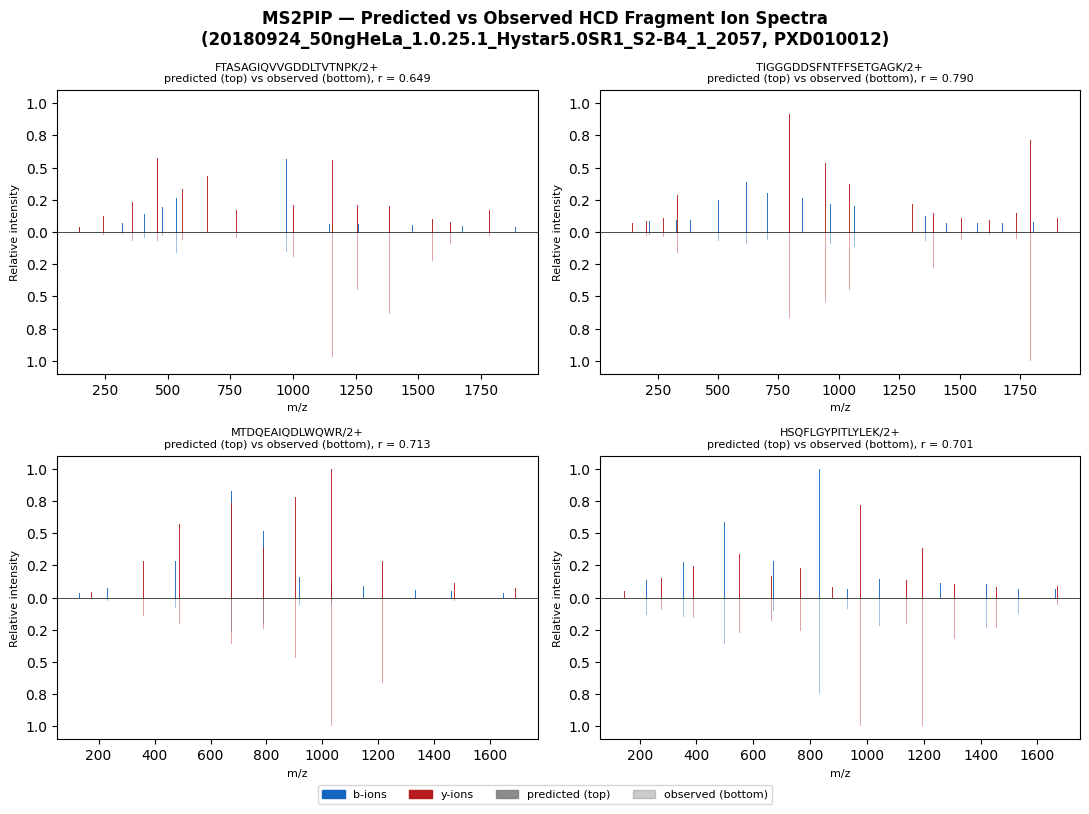

In [75]:
def plot_predicted_vs_observed(ax, sample_idx, ms2pip_df, obs_df, row):
    pred = ms2pip_df[ms2pip_df["sample_idx"] == sample_idx]
    pred_max = pred["intensity"].max()
    obs_max = obs_df["intensity"].max()

    for ion_type, color in (("b", "#1565C0"), ("y", "#B71C1C")):
        p = pred[pred["ion_type"] == ion_type]
        ax.bar(p["mz"], p["intensity"] / pred_max, width=3, color=color, alpha=0.9)
        o = obs_df[obs_df["ion_type"] == ion_type]
        ax.bar(o["mz"], -(o["intensity"] / obs_max), width=3, color=color, alpha=0.4)

    # Pearson r on ions matched between prediction and observation
    merged = pred.merge(obs_df, on=["ion_type", "position"], suffixes=("_pred", "_obs"))
    r, _ = pearsonr(merged["intensity_pred"], merged["intensity_obs"])

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("m/z", fontsize=8)
    ax.set_ylabel("Relative intensity", fontsize=8)
    ax.set_title(
        f"{row['Sequence']}/{int(row['Charge'])}+\n"
        f"predicted (top) vs observed (bottom), r = {r:.3f}",
        fontsize=8,
    )
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{abs(x):.1f}"))


handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1565C0", label="b-ions"),
    plt.Rectangle((0, 0), 1, 1, color="#B71C1C", label="y-ions"),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.9, label="predicted (top)"),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.4, label="observed (bottom)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, idx in zip(axes.flat, range(len(obs_psms))):
    plot_predicted_vs_observed(ax, idx, ms2pip_df, obs_peaks[idx], obs_psms.iloc[idx])

fig.legend(
    handles=handles, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02)
)
fig.suptitle(
    "MS2PIP — Predicted vs Observed HCD Fragment Ion Spectra\n"
    f"({RAW_RUN}, PXD010012)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### 4.3 Spectral angle across all reference spectra

Four spectra are enough to inspect individual peaks, but not to judge overall accuracy.
We now predict a spectrum for every one of the `msms` reference PSMs from Section 4.1
(not just the top 4) and score each predicted/observed pair with the **spectral angle**
(SA):

$$SA = 1 - \frac{2 \arccos(\cos\theta)}{\pi}$$

where $\cos\theta$ is the cosine similarity between the predicted and observed
intensity vectors, restricted to the b-/y-ions matched in both. SA ranges from 0 (no
similarity) to 1 (identical spectra) and, unlike Pearson r, is not dominated by the
single most intense peak, which makes it the standard metric for spectrum library
searching and rescoring (e.g. in MS²Rescore).

In [76]:
bulk_psms = msms.reset_index(drop=True)
bulk_peaks = {i: parse_observed_peaks(row) for i, row in bulk_psms.iterrows()}

bulk_psm_list = PSMList(
    psm_list=[
        PSM(peptidoform=row["proforma"], spectrum_id=str(i))
        for i, row in bulk_psms.iterrows()
    ]
)
bulk_results = list(predict_batch(bulk_psm_list, model="timsTOF"))
print(
    f"MS2PIP: {len(bulk_results)} peptides predicted for the spectral angle benchmark"
)

bulk_ms2pip_rows = []
for i, result in enumerate(bulk_results):
    for ion_type in ("b", "y"):
        for pos, (mz, intensity) in enumerate(
            zip(result.theoretical_mz[ion_type], result.predicted_intensity[ion_type]),
            start=1,
        ):
            bulk_ms2pip_rows.append(
                {
                    "sample_idx": i,
                    "ion_type": ion_type,
                    "position": pos,
                    "intensity": 2 ** float(intensity),
                }
            )
bulk_ms2pip_df = pd.DataFrame(bulk_ms2pip_rows)


def spectral_angle(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df, on=["ion_type", "position"], suffixes=("_pred", "_obs")
    )
    if len(merged) < 2:
        return np.nan
    p, o = merged["intensity_pred"].values, merged["intensity_obs"].values
    cos_sim = np.clip(np.dot(p, o) / (np.linalg.norm(p) * np.linalg.norm(o)), -1, 1)
    return 1 - 2 * np.arccos(cos_sim) / np.pi


# Group once instead of re-filtering bulk_ms2pip_df on every iteration (O(n) vs O(n^2))
bulk_pred_by_idx = dict(tuple(bulk_ms2pip_df.groupby("sample_idx")))
spectral_angles = np.array(
    [
        spectral_angle(bulk_pred_by_idx[i], bulk_peaks[i])
        for i in range(len(bulk_psms))
        if i in bulk_pred_by_idx
    ]
)
spectral_angles = spectral_angles[~np.isnan(spectral_angles)]
print(
    f"Spectral angle over {len(spectral_angles)} spectra: "
    f"median = {np.median(spectral_angles):.3f}, "
    f"mean = {spectral_angles.mean():.3f}"
)

MS2PIP: 590 peptides predicted for the spectral angle benchmark
Spectral angle over 590 spectra: median = 0.674, mean = 0.669


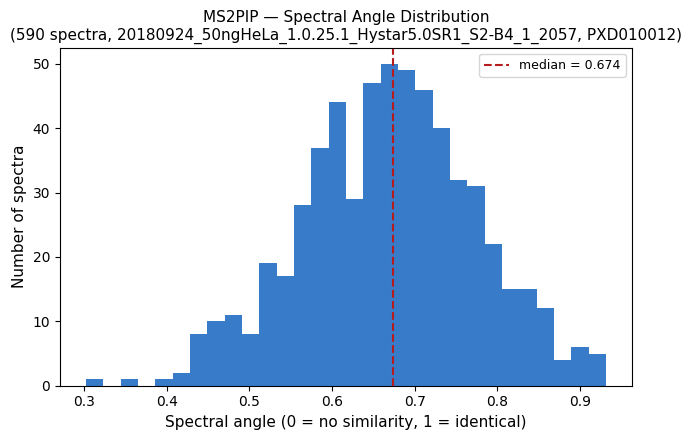

In [85]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(spectral_angles, bins=30, color="#1565C0", alpha=0.85)
ax.axvline(
    np.median(spectral_angles),
    color="#B71C1C",
    linestyle="--",
    linewidth=1.5,
    label=f"median = {np.median(spectral_angles):.3f}",
)
ax.set_xlabel("Spectral angle (0 = no similarity, 1 = identical)", fontsize=11)
ax.set_ylabel("Number of spectra", fontsize=11)
ax.set_title(
    f"MS2PIP — Spectral Angle Distribution\n"
    f"({len(spectral_angles)} spectra, {RAW_RUN}, PXD010012)",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. DeepLC: Retention Time Prediction

[DeepLC](https://github.com/compomics/DeepLC) predicts peptide retention time using a
convolutional neural network. The model encodes the peptide by its atomic composition, with modification information embedded at each position.

Because RT depends on the specific LC gradient, column chemistry, and instrument setup,
DeepLC outputs are in model-relative units and need to be adapted to a specific LC
system before they are meaningful. We compare three ways of doing so:

1. **Raw** (`deeplc.predict`): the model's native output, with no adaptation at all.
2. **Calibrated** (`deeplc.predict_and_calibrate`): a monotonic spline is fitted between
   the raw predictions and the observed RTs of a set of anchor PSMs, and applied to all
   predictions. This only rescales the output — the underlying model weights are
   untouched.
3. **Fine-tuned** (`deeplc.finetune_and_predict`): the model itself is fine-tuned
   (further trained) on the anchor PSMs before predicting, so it can also correct
   sequence-specific errors that a simple rescaling cannot.

We use 50 randomly selected PSMs as anchors for both calibration and fine-tuning, and
predict all 500 with each of the three strategies.

> **Practical note**: in a real analysis you would typically use hundreds of
> confidently identified PSMs from the same LC run as anchors.
> Here we use 50 for demonstration purposes.

In [ ]:
# Select 50 anchor PSMs (retention_time already set) for calibration and fine-tuning
cal_indices = sample.sample(50, random_state=7).index.tolist()
cal_psm_list = PSMList(psm_list=[psm_list[i] for i in cal_indices])

obs_rt = sample["rt_min"].values

pred_rt_raw = deeplc.predict(psm_list)
pred_rt_cal = deeplc.predict_and_calibrate(psm_list, cal_psm_list)
pred_rt_ft = deeplc.finetune_and_predict(psm_list, cal_psm_list)

deeplc_results = {}
for label, pred_rt in (
    ("raw", pred_rt_raw),
    ("calibrated", pred_rt_cal),
    ("fine-tuned", pred_rt_ft),
):
    mae = np.mean(np.abs(pred_rt - obs_rt))
    r, _ = pearsonr(pred_rt, obs_rt)
    deeplc_results[label] = {"pred_rt": pred_rt, "mae": mae, "r": r}
    print(f"DeepLC {label:>10}   MAE = {mae:6.2f} min  |  Pearson r = {r:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for ax, (label, res) in zip(axes, deeplc_results.items()):
    pred_rt = res["pred_rt"]
    lo = min(obs_rt.min(), pred_rt.min()) - 2
    hi = max(obs_rt.max(), pred_rt.max()) + 2
    ax.scatter(obs_rt, pred_rt, alpha=0.5, s=12, color="#1565C0", linewidths=0)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x")
    ax.set_xlabel("Observed RT (min)", fontsize=11)
    ax.set_title(
        f"{label}\nMAE = {res['mae']:.2f} min,  r = {res['r']:.4f}", fontsize=11
    )
    ax.legend(fontsize=9)

axes[0].set_ylabel("Predicted RT (min or model-relative units)", fontsize=10)
fig.suptitle("DeepLC — Retention Time: Raw vs Calibrated vs Fine-tuned", fontsize=13)
plt.tight_layout()
plt.show()

### Interpreting the RT prediction

Each point is one PSM; the dashed line is the ideal y = x diagonal. Scatter around
the diagonal reflects prediction error. A Pearson r close to 1 means the model
correctly ranks peptides by elution order; MAE quantifies the absolute error in minutes.

**Raw** predictions already correlate well with observed RT (peptides are ranked
correctly), but the absolute values are off — they are model-relative, not tied to
this specific gradient. **Calibration** fixes this with a single spline fit on the
anchor PSMs, without touching the underlying model, and already brings the MAE down to
about 2 minutes. **Fine-tuning** adapts the model weights themselves to the anchor
PSMs, which can further reduce the error, especially for peptides whose elution
behaviour is not well captured by the spline alone (e.g. after a gradient or column
change) — at the cost of extra compute for the fine-tuning step and, with only 50
anchors, some risk of overfitting to them.

The PSMs benchmarked here were run on a single, fixed ~45 min gradient (Section 3), so
a MAE of about 2 minutes after calibration corresponds to a relative error of roughly
4-5 %. This is sufficient for downstream applications such as peptide rescoring
(Percolator, MS²Rescore) and DIA library generation, where the goal is accurate rank
ordering rather than exact minute-level placement.

Systematic curvature in the scatter (S-shaped residuals) would indicate that the
calibration spline needs more anchor PSMs or a wider RT range to anchor on.

> **Why this matters**: the two variants of this dataset behave very differently.
> Restricting to `PT=True` (single gradient) gives calibrated Pearson r ≈ 0.95-0.96.
> Using `PT=False` instead — which pools several different gradient lengths without a
> run identifier to separate them — keeps Pearson r below 0.2 even after calibration,
> even though the *rank* correlation (Spearman) is still reasonable. A single linear
> (or spline) RT calibration is only meaningful within one LC system; silently mixing
> runs with different gradients breaks it, which is exactly the kind of bug that is easy
> to miss when only skimming summary statistics.


## 6. IM2Deep: Collisional Cross-Section Prediction

[IM2Deep](https://github.com/compomics/IM2Deep) predicts the collisional cross-section
(CCS) of peptide ions. CCS is a measure of how a peptide ion's three-dimensional shape
affects its drift time through a buffer gas in an ion mobility device. It is an intrinsic
physicochemical property of a peptide ion at a given charge state.

CCS is measured on timsTOF instruments using trapped ion mobility spectrometry (TIMS).
Combined with RT, it provides a second orthogonal dimension for peptide identification
and scoring. IM2Deep uses the same `PSMList` interface as DeepLC.

In [ ]:
# Reuse the PSMList built for MS2PIP (includes charge encoded in ProForma string)
pred_ccs = im2deep.predict(psm_list)
obs_ccs = sample["CCS"].values

mare_ccs = np.mean(np.abs(pred_ccs - obs_ccs) / obs_ccs) * 100
r_ccs, _ = pearsonr(pred_ccs, obs_ccs)
print(f"IM2Deep  MARE = {mare_ccs:.2f}%  |  Pearson r = {r_ccs:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(obs_ccs, pred_ccs, alpha=0.5, s=12, color="#2E7D32", linewidths=0)
lo = min(obs_ccs.min(), pred_ccs.min()) - 5
hi = max(obs_ccs.max(), pred_ccs.max()) + 5
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x")
ax.set_xlabel("Observed CCS (Å²)", fontsize=11)
ax.set_ylabel("Predicted CCS (Å²)", fontsize=11)
ax.set_title(
    f"IM2Deep — Collisional Cross-Section\nMARE = {mare_ccs:.2f}%,  r = {r_ccs:.4f}",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the CCS prediction

CCS values for doubly charged tryptic peptides typically fall between 300 and 550 Å²,
with larger peptides having higher CCS. The tight clustering around the diagonal
(MARE < 2 %) reflects that CCS is largely determined by amino acid composition and
sequence — properties that the model captures well.


## 6.1 Multiple conformers: a real bimodal ion mobilogram

A single peptide ion can populate **more than one gas-phase conformation** — for
example through cis/trans isomerisation around a proline, or alternative
intramolecular charge arrangements. Each conformation drifts through the TIMS cell at
a different rate, so the same precursor can show up as two (or more) separated peaks
in the ion mobility dimension, at the same m/z and (nearly) the same retention time.
The single-conformer model used above always predicts one CCS value per peptide, so it
cannot represent this. IM2Deep also ships a **multi-conformer model** that predicts
two CCS values per peptide.

To demonstrate this on real data, we searched the MaxQuant `evidence.txt` table for the
same run used in Section 4 for a peptide that was identified **twice** — same modified
sequence, same charge, essentially the same retention time — but at two clearly
different ion mobility values. This turned up:

`VETGVLKPGMVVTFAPVNVTTEVK`, charge 3+, m/z 839.13, RT ≈ 244.7-244.8 s, identified once
at ion mobility index 321 and once at index 621.

We now extract the real ion mobilogram for this precursor directly from the Bruker
`.d` file to see both conformers, and compare it to what the IM2Deep multi-conformer
model predicts.

> **Note**: this downloads ~1.4 GB (the `analysis.tdf`/`analysis.tdf_bin` pair for one
> raw file, extracted directly from the PRIDE FTP archive without downloading the full,
> much larger raw-data submission) and requires `alphatims`. This is by far the
> heaviest step in the tutorial; it is cached to disk so it only runs once.

In [82]:
RAW_ZIP_URL = (
    "https://ftp.pride.ebi.ac.uk/pride/data/archive/2018/11/PXD010012/HeLa_5min_raw.zip"
)
RAW_D_ENTRY = f"{RAW_RUN}.d/"
RAW_D_DIR = "data/2057.d"

if not os.path.exists(RAW_D_DIR):
    os.makedirs(RAW_D_DIR, exist_ok=True)
    print("Downloading analysis.tdf + analysis.tdf_bin (~1.4 GB)...")
    with remotezip.RemoteZip(RAW_ZIP_URL) as zf:
        for fname in ("analysis.tdf", "analysis.tdf_bin"):
            with zf.open(RAW_D_ENTRY + fname) as src, open(
                os.path.join(RAW_D_DIR, fname), "wb"
            ) as dst:
                for chunk in iter(lambda: src.read(1 << 20), b""):
                    dst.write(chunk)
            print(f"  {fname} done")

print(f"Raw data available in {RAW_D_DIR}/")

Raw data available in data/2057.d/


In [83]:
CONFORMER_SEQUENCE = "VETGVLKPGMVVTFAPVNVTTEVK"
CONFORMER_CHARGE = 3
CONFORMER_MZ = 839.132859
RT_WINDOW = (247.7 - 4, 247.7 + 4)  # seconds, covers both identifications
PPM_TOLERANCE = 10e-6

tims_data = alphatims.bruker.TimsTOF(RAW_D_DIR)

mz_lo = CONFORMER_MZ * (1 - PPM_TOLERANCE)
mz_hi = CONFORMER_MZ * (1 + PPM_TOLERANCE)
precursor_frame = tims_data[slice(*RT_WINDOW), :, 0, slice(mz_lo, mz_hi), "df"]

# Bin into a smoothed mobilogram and pick the two dominant conformer peaks
n_bins = 150
edges = np.linspace(
    precursor_frame["mobility_values"].min() - 0.02,
    precursor_frame["mobility_values"].max() + 0.02,
    n_bins + 1,
)
mobility_axis = (edges[:-1] + edges[1:]) / 2
intensity_axis, _ = np.histogram(
    precursor_frame["mobility_values"],
    bins=edges,
    weights=precursor_frame["intensity_values"],
)
intensity_smooth = gaussian_filter1d(intensity_axis, sigma=3)

bin_width = mobility_axis[1] - mobility_axis[0]
peak_idx, _ = find_peaks(
    intensity_smooth,
    height=intensity_smooth.max() * 0.3,
    distance=int(0.09 / bin_width),
)
ccs_axis = im2deep.im2ccs(mobility_axis, CONFORMER_MZ, CONFORMER_CHARGE)
observed_ccs = np.sort(ccs_axis[peak_idx])
print(f"Observed conformer CCS values: {observed_ccs.round(1)} Å²")

Observed conformer CCS values: [605.5 694.5] Å²


IM2Deep multi-conformer predicted CCS:  [609.  677.1] Å²
IM2Deep single-conformer predicted CCS: 590.6 Å²


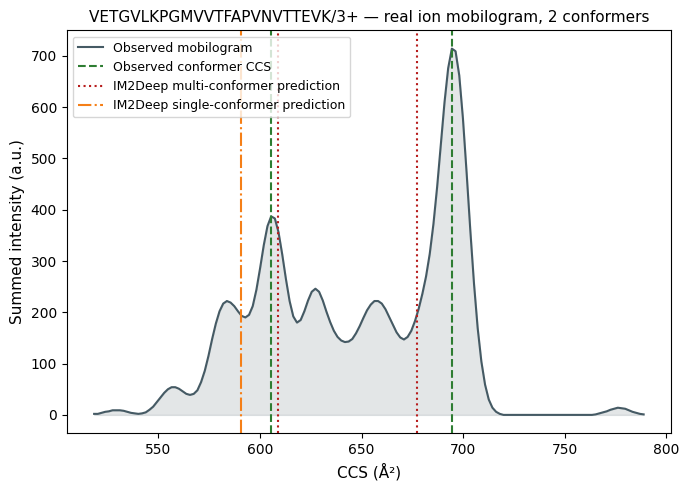

In [88]:
conformer_psm_list = PSMList(
    psm_list=[
        PSM(
            peptidoform=f"{CONFORMER_SEQUENCE}/{CONFORMER_CHARGE}",
            spectrum_id="0",
        )
    ]
)
predicted_ccs = np.sort(im2deep.predict(conformer_psm_list, multi=True))
predicted_ccs_single = im2deep.predict(conformer_psm_list)
print(f"IM2Deep multi-conformer predicted CCS:  {predicted_ccs.round(1)} Å²")
print(f"IM2Deep single-conformer predicted CCS: {predicted_ccs_single:.1f} Å²")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    ccs_axis,
    intensity_smooth,
    color="#455A64",
    linewidth=1.5,
    label="Observed mobilogram",
)
ax.fill_between(ccs_axis, intensity_smooth, color="#455A64", alpha=0.15)

for ccs in observed_ccs:
    ax.axvline(ccs, color="#2E7D32", linestyle="--", linewidth=1.5)
for ccs in predicted_ccs:
    ax.axvline(ccs, color="#B71C1C", linestyle=":", linewidth=1.5)
ax.axvline(predicted_ccs_single, color="#F57F17", linestyle="-.", linewidth=1.5)

ax.plot([], [], color="#2E7D32", linestyle="--", label="Observed conformer CCS")
ax.plot(
    [], [], color="#B71C1C", linestyle=":", label="IM2Deep multi-conformer prediction"
)
ax.plot(
    [],
    [],
    color="#F57F17",
    linestyle="-.",
    label="IM2Deep single-conformer prediction",
)
ax.set_xlabel("CCS (Å²)", fontsize=11)
ax.set_ylabel("Summed intensity (a.u.)", fontsize=11)
ax.set_title(
    f"{CONFORMER_SEQUENCE}/{CONFORMER_CHARGE}+ — real ion mobilogram, "
    f"{len(observed_ccs)} conformers",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the multi-conformer prediction

The observed mobilogram shows two clearly separated peaks for the same precursor
m/z — direct evidence of two co-occurring gas-phase conformations. Converting their
apex mobility to CCS with the Mason-Schamp equation (`im2deep.im2ccs`) gives two
observed CCS values, which line up well with the two values predicted by IM2Deep's
multi-conformer model, without using any information from this specific run. The
single-conformer model's prediction, also shown on the plot, does not correspond well to the highest ion mobility peak, but rather to the other, smaller observed peak, but it also doesnt and does not overlap with either of them.

This matters in practice: if a bimodal precursor is treated as a single feature during
quantification, its intensity may be under- or over-estimated depending on which
conformer's mobility window is integrated, and a single predicted CCS is not enough to
disambiguate between the two.

## Key points

- MS2PIP, DeepLC, and IM2Deep all consume peptides in ProForma notation and predict a
  distinct physicochemical property from the sequence and charge state alone.
- MS2PIP's predicted fragment ion intensities can be validated directly against
  observed, matched fragment ions from a real search result, both spectrum-by-spectrum
  and, at scale, as a spectral angle distribution across hundreds of spectra.
- DeepLC's retention time predictions are model-relative; calibrating against a set of
  anchor PSMs with known RT already brings them onto the LC gradient's scale, and
  fine-tuning the model on those same anchors can improve accuracy further.
- IM2Deep's multi-conformer model can predict two CCS values for peptides that
  populate two distinct gas-phase conformations, as confirmed here with a real,
  bimodal ion mobilogram extracted from a Bruker `.d` file — the single-conformer
  model's prediction for the same peptide falls between the two observed peaks and
  matches neither.
- Together, these three predictors provide the feature set needed to build in silico
  spectral libraries or to rescore PSMs (see the [MS²Rescore tutorial](../posts/2026-06-11-ms2rescore.qmd)).

## Next steps

- [MS²Rescore tutorial](../posts/2026-06-11-ms2rescore.qmd): use these predictors as
  features to rescore real PSMs and improve identifications at a fixed FDR.
- [MS2PIP documentation](https://ms2pip.readthedocs.io)
- [DeepLC documentation](https://deeplc.readthedocs.io)
- [IM2Deep repository](https://github.com/compomics/IM2Deep)

## References

- Gabriels *et al.*, *Nucleic Acids Research* (2019). MS²PIP.
  [doi:10.1093/nar/gkz299](https://doi.org/10.1093/nar/gkz299)
- Bouwmeester *et al.*, *Nature Methods* (2021). DeepLC.
  [doi:10.1038/s41592-021-01301-5](https://doi.org/10.1038/s41592-021-01301-5)
- Meier *et al.*, *Nature Communications* (2021). Source dataset (timsTOF IM-CCS).
  [doi:10.1038/s41467-021-21352-8](https://doi.org/10.1038/s41467-021-21352-8)
- Meier *et al.*, *Journal of Proteome Research* (2018). PASEF method and source raw
  data (PXD010012) used for the observed spectrum and ion mobilogram.
  [doi:10.1021/acs.jproteome.7b00858](https://doi.org/10.1021/acs.jproteome.7b00858)